<a href="https://colab.research.google.com/github/Teivak/FaceRecognitionProject/blob/main/4_HW_RecognitionPipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Модели для пайплана**
  **Детекция лиц**

*Нашёл SCRFD от insightface, работает идеально, распознаёт лица даже лучше меня.*

`Конкретно scrfd_10g_bnkps`


---


**Получение лэндмарков**

*Наша StackedHourglassNetwork из первого ноутбука*

*Параметры:*


```
num_stacks = 4
depth = 5
in_channels = 256
out_channels = 256
num_landmarks = 5
```


---


**Распознавание**

*Наша FaceRecognitionArcFaceModel (ArcFace на удивление лучше справился с задачей пайплайна)*



```
embedding_dim=512
num_classes=1944
s=64.0
m=0.4
```






# **FaceRecognitionPipeline**

## Весь необходимый импорт

In [3]:
!pip install insightface onnxruntime-gpu
!pip install opencv-python

  Installing build dependencies ... - \ | / - \ | / - done
  Getting requirements to build wheel ... - done
  Preparing metadata (pyproject.toml) ... - done
  Using cached cython-3.2.4-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (7.5 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.6/252.6 MB 15.8 MB/s  0:00:15
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 64.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 583.0/583.0 kB 29.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 60.6 MB/s  0:00:00
Using cached cython-3.2.4-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (3.4 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 63.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 58.6 MB/s  0:00:00
  Created wheel for insightface: filename=insightface-0.7.3-cp313-cp313-linux_x86_64.whl size=882808 sha256=f0ea1c3af69cdd

In [23]:
def heatmaps_to_landmarks(heatmaps):
    """
    Преобразует карты активации (heatmaps) в координаты ключевых точек,
    находя положение максимального значения.
    heatmaps: (batch_size, num_landmarks, H, W)
    Возвращает: (batch_size, num_landmarks, 2), где 2 это (x, y)
    """
    batch_size, num_landmarks, H, W = heatmaps.shape
    landmarks = torch.zeros(batch_size, num_landmarks, 2, device=heatmaps.device)
    for b in range(batch_size):
        for l in range(num_landmarks):
            max_val_idx = torch.argmax(heatmaps[b, l].view(-1))
            y = max_val_idx // W
            x = max_val_idx % W
            landmarks[b, l, 0] = x
            landmarks[b, l, 1] = y
    return landmarks

In [ ]:
from insightface.app import FaceAnalysis
import cv2
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import torchvision.transforms.v2 as T
from torchvision.tv_tensors import KeyPoints
from PIL import Image
import numpy as np
import torch.nn.functional as F
import torch
from torch import device
import os
import sys

device = "cuda" if torch.cuda.is_available() else "cpu"
project_path = 'PROJECT/FaceAlignment/'

# Импортируем наши модели и датасет
%run PROJECT/FaceAlignment/FaceRecognitionDataset.py
%run PROJECT/FaceAlignment/hourglass_network.py
%run PROJECT/FaceAlignment/FaceRecognitionCEModel.py # Не использьзуется
%run PROJECT/FaceAlignment/FaceRecognitionArcFaceModel.py


## Код пайплайна

In [40]:
# Модель детекции сильно засоряет вывод, поэтому добавил это
class SuppressOutput:
    """Менеджер контекста для подавления stdout и stderr."""
    def __enter__(self):
        self._original_stdout = sys.stdout
        self._original_stderr = sys.stderr
        self._devnull = open(os.devnull, 'w')
        sys.stdout = self._devnull
        sys.stderr = self._devnull

    def __exit__(self, exc_type, exc_val, exc_tb):
        sys.stdout = self._original_stdout
        sys.stderr = self._original_stderr
        self._devnull.close()

class FaceRecognitionPipeline:
    def __init__(self):
        #______________________ЗАГРУЗКА МОДЕЛИ ДЛЯ ДЕТЕКЦИИ ЛИЦ___________________________
        with SuppressOutput():
            detection_model = FaceAnalysis(allowed_modules=['detection'], det_name='scrfd_10g_bnkps')
            detection_model.prepare(ctx_id=0, det_size=(640, 640)) # ctx_id=0 для GPU
        self.detection_model = detection_model


        #__________________ЗАГРУЗКА МОДЕЛИ ДЛЯ РАСПОЗНАВАНИЯ ЛЭНДМАРКОВ____________________
        num_stacks = 4
        depth = 5
        in_channels = 256
        out_channels = 256
        num_landmarks = 5

        landmarks_model = StackedHourglassNetwork(num_stacks, depth, in_channels, out_channels, num_landmarks).to(device)
        landmarks_model.load_state_dict(torch.load(f'{project_path}/best_landmark_model.pth'))
        self.landmarks_model = landmarks_model
        self.landmarks_model.eval()

        #______________________ЗАГРУЗКА МОДЕЛИ ДЛЯ РАСПОЗНАВАНИЯ___________________________
        # Бывшая инициализация CE model
        # face_recognition_model = FaceRecognitionModel(embedding_dim=512, num_classes=1944)
        # face_recognition_model.load_state_dict(torch.load(f'{project_path}/FR_linear.pth'))
        face_recognition_model = FaceRecognitionArcFaceModel(embedding_dim=512, num_classes=1944, s=64.0, m=0.4)
        face_recognition_model.load_state_dict(torch.load(f'{project_path}/FR_ArcFace.pth'))
        face_recognition_model.to(device)
        self.face_recognition_model = face_recognition_model
        self.face_recognition_model.eval()

        # ____________________ИНИЦИАЛИЗАЦИЯ ОСНОВНЫХ ТРАНСФОРМАЦИЙ_________________________`
        self.resize_and_pad_transform = ResizeAndPad(output_size=(128, 128))

        self.pil_to_tensor_transform = T.Compose([
            T.PILToTensor(),
            T.ConvertImageDtype(torch.float)
        ])

        self.normalize = T.Compose([
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])

        self.face_align_transform = FaceAlign(
            target_size=(128, 128),
            target_left_eye=(0.28, 0.35),
            target_right_eye=(0.72, 0.35),
            target_mouth_y=0.75
        )

        #_____________________________________________________________________________________


    def _process_single_image(self, item):
        # 1. Загрузка изображения
        image_path = item['image_path']
        input_img_bgr = cv2.imread(image_path) # Детекция работает с BGR
        if input_img_bgr is None:
            print(f"ОШИБКА: Не удалось загрузить изображение из {image_path}")
            return [] # Возвращаем пустой список, если загрузка изображения не удалась

        # Преобразуем BGR в RGB PIL изображение для трансформаций torchvision
        original_rgb_pil_image = Image.fromarray(cv2.cvtColor(input_img_bgr, cv2.COLOR_BGR2RGB))

        # 2. Выполняем детекцию лиц
        faces = self.detection_model.get(input_img_bgr)
        if len(faces) == 0:
            print(f"На изображении {image_path.split('/')[-1]} не было найдено лиц.")
            return []

        all_face_data = []

        for face in faces:
            # Извлекаем координаты ббокса (x1, y1, x2, y2)
            bbox = face.bbox.astype(int)
            x1, y1, x2, y2 = bbox[0], bbox[1], bbox[2], bbox[3]

            # Убеждаемся, что точки ббокса находятся в границах изображения
            x1 = max(0, x1)
            y1 = max(0, y1)
            x2 = min(original_rgb_pil_image.width, x2)
            y2 = min(original_rgb_pil_image.height, y2)

            # Обрезаем original_rgb_pil_image для получения области лица для предсказания лендмарков
            cropped_pil_image_for_lm = original_rgb_pil_image.crop((x1, y1, x2, y2))
            cropped_width_lm, cropped_height_lm = cropped_pil_image_for_lm.size

            # Преобразуем обрезанное PIL изображение в tv_tensors.Image (тензор)
            cropped_tv_image_for_lm = self.pil_to_tensor_transform(cropped_pil_image_for_lm)

            # Создаем фиктивный объект KeyPoints для ResizeAndPad для входных данных модели лэндмарков
            dummy_keypoints_obj_lm = KeyPoints(torch.empty(0, 2), canvas_size=(cropped_height_lm, cropped_width_lm))

            # Применяем ResizeAndPad и Normalize для входных данных предсказания лэндмарков
            resized_padded_data_lm = self.resize_and_pad_transform({'image': cropped_tv_image_for_lm, 'keypoints': dummy_keypoints_obj_lm})
            preprocessed_tensor_lm = self.normalize(resized_padded_data_lm['image'])

            # Предсказываем хитмапы с помощью модели лэндмарков
            input_tensor_lm = preprocessed_tensor_lm.unsqueeze(0).to(device)
            output_heatmaps_list = self.landmarks_model(input_tensor_lm)
            heatmap = output_heatmaps_list[-1].squeeze(0).cpu()

            # Преобразуем хитмапы в координаты лендмарков (пространство 64x64)
            batched_heatmap_tensor = heatmap.unsqueeze(0)
            landmarks_64x64_tensor = heatmaps_to_landmarks(batched_heatmap_tensor)
            heatmap_max_indices = [(pt[0].item(), pt[1].item()) for pt in landmarks_64x64_tensor.squeeze(0)]

            # Масштабируем ключевые точки до 128x128 (размер входного изображения модели)
            scaled_to_128x128_landmarks = [
                (x * (128 / heatmap.shape[2]), y * (128 / heatmap.shape[1]))
                for x, y in heatmap_max_indices
            ]

            # Обратное преобразование ResizeAndPad для получения лендмарков в исходном обрезанном пространстве ббокса
            target_w, target_h = 128, 128
            scale_factor = min(target_w / cropped_width_lm, target_h / cropped_height_lm)

            resized_w_orig = cropped_width_lm * scale_factor
            resized_h_orig = cropped_height_lm * scale_factor

            pad_w_left = (target_w - resized_w_orig) / 2
            pad_h_top = (target_h - resized_h_orig) / 2

            landmarks_in_original_bbox_space = []
            for lx_128, ly_128 in scaled_to_128x128_landmarks:
                lx_unpadded = lx_128 - pad_w_left
                ly_unpadded = ly_128 - pad_h_top

                lx_original_cropped = lx_unpadded / scale_factor
                ly_original_cropped = ly_unpadded / scale_factor

                landmarks_in_original_bbox_space.append((lx_original_cropped, ly_original_cropped))

            # Создаем объект KeyPoints для FaceAlign с относительными лэндмарками к обрезанному изображению
            keypoints_for_align = KeyPoints(torch.tensor(landmarks_in_original_bbox_space, dtype=torch.float),
                                            canvas_size=(cropped_height_lm, cropped_width_lm))

            # Снова обрезаем original_rgb_pil_image для FaceAlign
            cropped_pil_image_for_align = original_rgb_pil_image.crop((x1, y1, x2, y2))
            cropped_tv_image_for_align = self.pil_to_tensor_transform(cropped_pil_image_for_align)

            # Применяем трансформацию FaceAlign
            aligned_data = self.face_align_transform({'image': cropped_tv_image_for_align, 'keypoints': keypoints_for_align})
            aligned_face_tensor = aligned_data['image']

            # Применяем нормализацию для модели распознавания лиц
            normalized_aligned_face_tensor = self.normalize(aligned_face_tensor)

            # Получаем эмбеддинги из базовой модели
            input_batch_fr = normalized_aligned_face_tensor.unsqueeze(0).to(device)
            raw_embeddings = self.face_recognition_model.backbone(input_batch_fr)

            # Нормализуем эмебеддинги
            normalized_embeddings = F.normalize(raw_embeddings, p=2, dim=1)

            # Добавляем словарь с эмбеддингом, координатами ббокса и индексом изображения
            all_face_data.append({
                'embedding': normalized_embeddings.cpu(),
                'bbox': (x1, y1, x2, y2),
                'image_index': item['index']
            })

        print(f"Успешно извлечено {len(all_face_data)} данных о лицах из {image_path.split('/')[-1]}.")
        return all_face_data

    def __call__(self, input_images_paths):
        # Подготавливаем список словарей, каждый из которых содержит image_path и его индекс
        images_to_process = []
        for i, path in enumerate(input_images_paths):
            images_to_process.append({'image_path': path, 'index': i})

        # Отключаем вычисления градиентов для инференса
        with torch.no_grad():
            all_faces_data = []
            for item in images_to_process:
                faces_data_from_single_image = self._process_single_image(item)
                all_faces_data.extend(faces_data_from_single_image)

            print(f"Всего обработано лиц: {len(all_faces_data)}")
            return all_faces_data

In [41]:
family2_1 = 'PROJECT/FaceAlignment/family2.1.jpg'
family2_2 = 'PROJECT/FaceAlignment/family2.2.jpg'

In [42]:
pipeline = FaceRecognitionPipeline()
input_image_paths = [family2_1, family2_2]
all_faces_data = pipeline(input_image_paths)

Успешно извлечено 8 данных о лицах из family2.1.jpg.
Успешно извлечено 8 данных о лицах из family2.2.jpg.
Всего обработано лиц: 16


In [43]:
import cv2
import matplotlib.pyplot as plt
import torch
import itertools

def compare_and_visualize_faces(all_faces_data, input_image_paths, similarity_threshold=0.6):
    """
    Организует сравнение и визуализацию лиц.

    Args:
        all_faces_data (list): Список словарей, где каждый словарь содержит
                                'embedding', 'bbox' и 'image_index' для обнаруженного лица.
        input_image_paths (list): Список путей к исходным входным изображениям.
        similarity_threshold (float): Минимальное косинусное сходство, необходимое для того,
                                      чтобы считать два лица одинаковыми.
    """
    # 1. Загружаем все исходные изображения в словарь для удобного доступа
    # Ключами будут индексы изображений, значениями - массивы NumPy в формате BGR
    original_images = {}
    for i, img_path in enumerate(input_image_paths):
        img = cv2.imread(img_path)
        if img is None:
            print(f"Внимание: Не удалось загрузить изображение из {img_path}. Пропускаем.")
            continue
        original_images[i] = img

    print(f"Загружено {len(original_images)} исходных изображений.")

    # Храним пары лиц, имеющих высокое сходство
    matched_pairs = []

    # Перебираем уникальные пары лиц в all_faces_data
    # Используем itertools.combinations для получения всех уникальных пар
    for face1, face2 in itertools.combinations(all_faces_data, 2):
        embedding1 = face1['embedding']
        embedding2 = face2['embedding']

        # Вычисляем косинусное сходство
        # F.cosine_similarity ожидает тензоры формы (N, D)
        similarity = torch.nn.functional.cosine_similarity(embedding1, embedding2).item()

        if similarity >= similarity_threshold:
            matched_pairs.append({
                'face1': face1,
                'face2': face2,
                'similarity': similarity
            })

    print(f"Найдено {len(matched_pairs)} совпадающих пар лиц выше порога сходства.")

    # Визуализируем совпадающие пары
    if matched_pairs:
        num_plots = len(matched_pairs)
        fig, axes = plt.subplots(num_plots, 2, figsize=(10, 5 * num_plots))

        # Убедимся, что axes всегда является 2D массивом для согласованной индексации
        if num_plots == 1:
            axes = [axes] # Превращаем его в список списков, если только одна строка

        for i, match in enumerate(matched_pairs):
            face1_data = match['face1']
            face2_data = match['face2']
            similarity = match['similarity']

            img_idx1 = face1_data['image_index']
            img_idx2 = face2_data['image_index']
            bbox1 = face1_data['bbox']
            bbox2 = face2_data['bbox']

            # Загружаем исходные изображения (или получаем из кэша)
            img1_original = original_images.get(img_idx1)
            img2_original = original_images.get(img_idx2)

            if img1_original is None or img2_original is None:
                print(f"Пропускаем визуализацию для пары из-за отсутствия изображения(й).")
                continue

            # Создаем копии для рисования ббоксов
            img1_display = img1_original.copy()
            img2_display = img2_original.copy()

            # Рисуем зеленые рамки
            cv2.rectangle(img1_display, (bbox1[0], bbox1[1]), (bbox1[2], bbox1[3]), (0, 255, 0), 2)
            cv2.rectangle(img2_display, (bbox2[0], bbox2[1]), (bbox2[2], bbox2[3]), (0, 255, 0), 2)

            # Отображаем изображения рядом
            ax1 = axes[i][0]
            ax2 = axes[i][1]

            ax1.imshow(cv2.cvtColor(img1_display, cv2.COLOR_BGR2RGB))
            ax1.set_title(f'Изображение {img_idx1}\nСходство: {similarity:.2f}')
            ax1.axis('off')

            ax2.imshow(cv2.cvtColor(img2_display, cv2.COLOR_BGR2RGB))
            ax2.set_title(f'Изображение {img_idx2}')
            ax2.axis('off')

        plt.tight_layout()
        plt.show()

Загружено 2 исходных изображений.
Найдено 8 совпадающих пар лиц выше порога сходства.


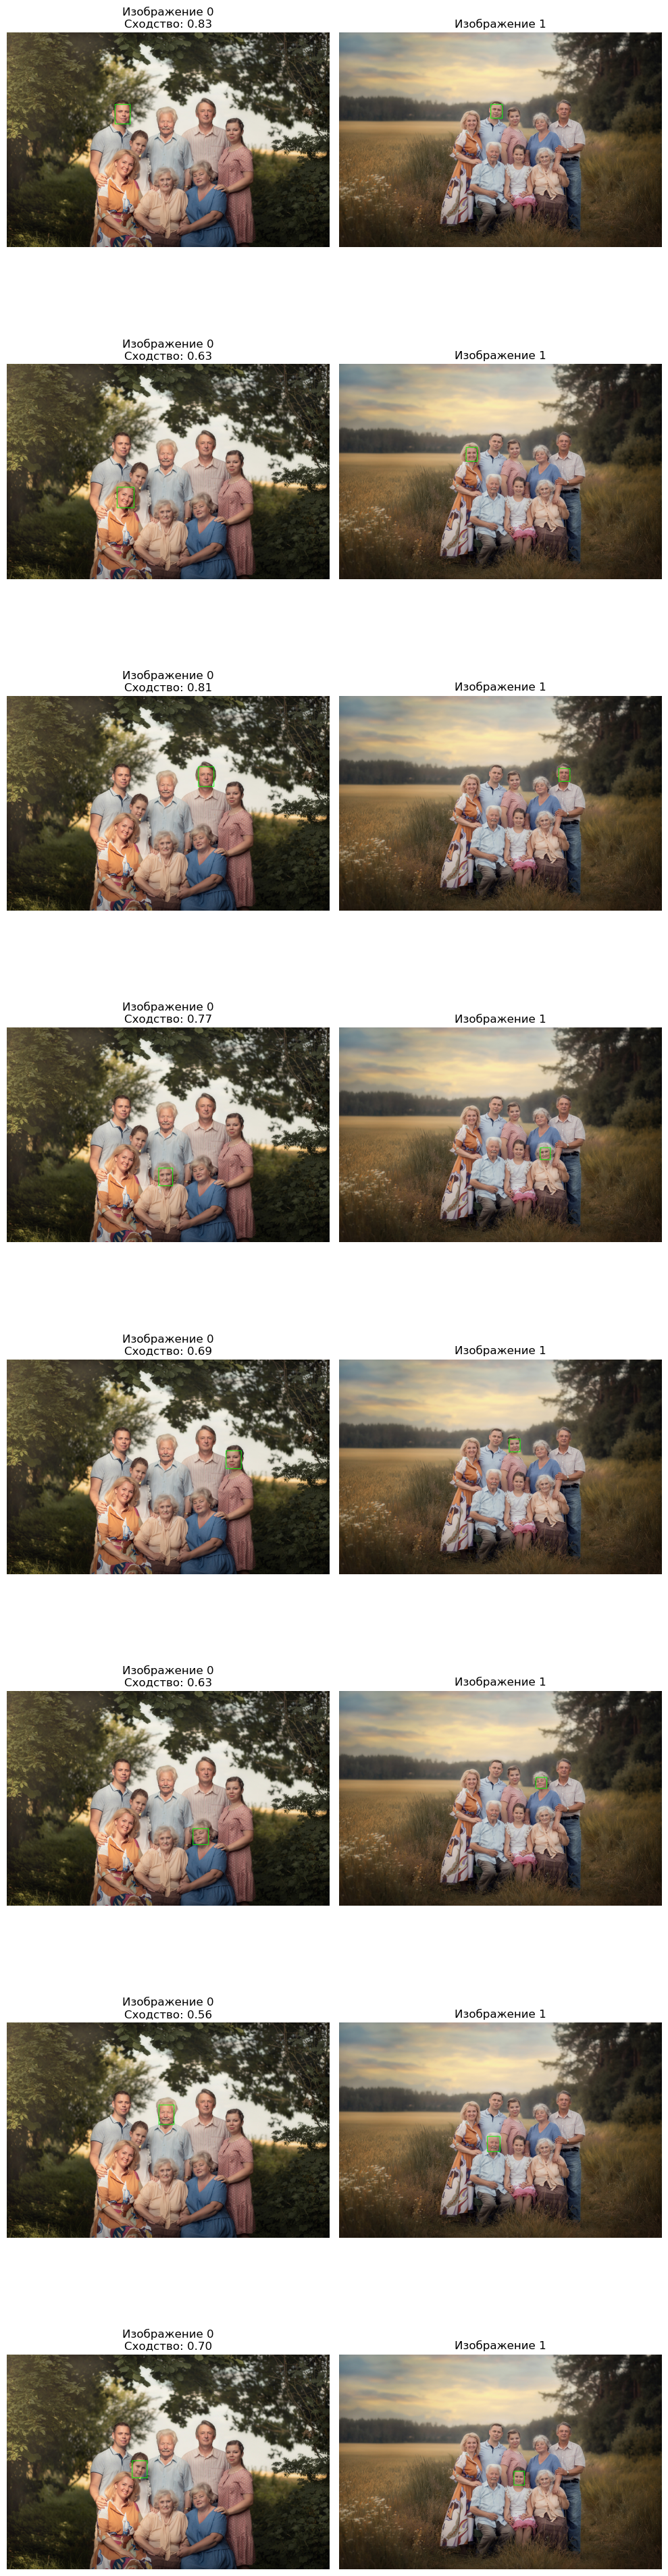

In [44]:
compare_and_visualize_faces(all_faces_data, input_image_paths, similarity_threshold=0.55)

Изначально использовалась модель с CE лоссом, но она никак не могла найти девочку, а когда я понизил порог, начала объединять её в один класс с матерью. ArcFace c этим справился лучше, хотя у него возникла сложность с нахождением деда (similarity = 0.56), из-за чего пришлось ставить порог 0.55. Несмотря на это, он всё ещё смог классифицировать всех людей верно без единой ошибки.

Довольно странно, учитывая результаты тестов. Может быть, это просто частный случай.